## АНАЛИЗ ДИСКУРСА ОБ ИНВАЛИДНОСТИ
### Россия vs Зарубежье


### УСТАНОВКА И ИМПОРТ БИБЛИОТЕК

In [ ]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Машинное обучение
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Графы и визуализация
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Анализ текста
from textblob import TextBlob
import re
from transformers import pipeline
import nltk
sentiment_ru = pipeline(
    "sentiment-analysis",
    model="blanchefort/rubert-base-cased-sentiment"
)
from collections import Counter, defaultdict
from itertools import combinations

sentiment_en = pipeline("sentiment-analysis")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Стиль визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11




Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### ПОДГОТОВКА ДАННЫХ

### Загрузка CSV файла

In [51]:
df = pd.read_csv("/Users/anastasia812/Desktop/dataframe.csv", encoding="utf-8", delimiter=";")

if df is None:
    print("CSV файл не загружен.")
else:
    print(f"Загружено {len(df)} текстов")
    print(f"\nДатасет:\n{df.head()}")
    

Загружено 126 текстов

Датасет:
    id country   source   is_disabled  \
0  1.0  Foreign   reels      Disabled   
1  2.0  Foreign   reels      Disabled   
2  3.0   Russia  статья  not_Disabled   
3  4.0   Russia  статья  not_Disabled   
4  5.0   Russia  статья  not_Disabled   

                                                text  
0  Have you ever seen someone like me and wonder,...  
1  And remember guys, you're not... you're not di...  
2  «Вы все можете сами!»: как обучают самостоятел...  
3  Приобретенная или хроническая инвалидность - э...  
4  «Что инвалид может дать здоровому?» Истории зн...  


### ОПРЕДЕЛЕНИЕ ТИПОВ НАРРАТИВОВ

In [ ]:
# Определяем маркеры для каждого типа нарратива
# ОСЬ 1: агентность vs патернализм
paternalistic_markers = [
    'жалость',
    'сострадание',
    'поддержка',
    'опека',
    'заботиться',
    'нуждающийся',
    'несмотря'
    'уязвимый',
    'беспомощный',
    'ограниченный',
    'страдающий',
    'особые потребности',
    'социальная помощь',
    'защита',
    'реабилитация',
    'подопечный',
    'зависимый',
    'пострадал',
    'помощь обществу',
    'милосердие',
    'спасать',
    'pity',
    'compassion',
    'care',
    'support',
    'assistance',
    'преодолел'
    'vulnerable',
    'needy',
    'dependent',
    'helpless',
    'suffering',
    'special needs',
    'rehabilitation',
    'protection',
    'charity',
    'aid',
    'relief',
    'welfare'
]

independent_markers = [
    'право',
    'равноправие',
    'свобода',
    'выбор',
    'контроль',
    'независимость',
    'самостоятельность',
    'агентность',
    'активизм',
    'требовать',
    'добиваться',
    'бороться',
    'критика',
    'система',
    'барьеры',
    'дискриминация',
    'доступность',
    'участие',
    'голос',
    'саморепрезентация',
    'идентичность',
    'rights',
    'equality',
    'autonomy',
    'independence',
    'agency',
    'empowerment',
    'advocacy',
    'activism',
    'demand',
    'challenge',
    'protest',
    'systemic',
    'barriers',
    'discrimination',
    'accessibility',
    'representation',
    'voice',
    'self-determination',
    'participation'
]

# ОСЬ 2: эмоция
pessimistic_markers = [
    'страдание',
    'трагедия',
    'тяжело',
    'невозможно',
    'беспомощность',
    'безнадёжность',
    'изоляция',
    'одиночество',
    'депрессия',
    'ограничение',
    'потеря',
    'страдать',
    'жертва',
    'проблема',
    'трудность',
    'кризис',
    'неспособность',
    'suffering',
    'tragedy',
    'hardship',
    'struggle',
    'impossible',
    'hopeless',
    'helplessness',
    'isolation',
    'loneliness',
    'depression',
    'limitation',
    'loss',
    'victim',
    'problem',
    'difficulty',
    'burden',
    'unable'
]

optimistic_markers = [
    'возможность',
    'надежда',
    'успех',
    'достижение',
    'развитие',
    'потенциал',
    'прогресс',
    'инновация',
    'решение',
    'рост',
    'вдохновение',
    'улучшение',
    'результат',
    'достижимый',
    'перспектива',
    'opportunity',
    'hope',
    'success',
    'achievement',
    'growth',
    'potential',
    'progress',
    'innovation',
    'solution',
    'improvement',
    'empowerment',
    'inspiration',
    'advancement',
    'breakthrough'

]
# Функция для подсчёта баллов по каждому типу нарратива
def get_scores(text):
    text_lower = str(text).lower()
    
    paternalistic_score = sum(1 for marker in paternalistic_markers if marker in text_lower)
    independent_score = sum(1 for marker in independent_markers if marker in text_lower)
    pessimistic_score = sum(1 for marker in pessimistic_markers if marker in text_lower)
    optimistic_score = sum(1 for marker in optimistic_markers if marker in text_lower)

    return {
        'paternalistic': paternalistic_score,
        'independent': independent_score,
        'pessimistic': pessimistic_score,
        'optimistic': optimistic_score
    }

# Функция для получения координат на плоскости
def get_coordinates(scores):
    x = (scores['independent'] - scores['paternalistic']) / \
        (scores['independent'] + scores['paternalistic'] + 1)
    
    y = (scores['optimistic'] - scores['pessimistic']) / \
        (scores['optimistic'] + scores['pessimistic'] + 1)

    return x, y

df['scores'] = df['text'].apply(get_scores)

df[['paternalistic_score',
    'independent_score',
    'pessimistic_score',
    'optimistic_score']] = pd.DataFrame(df['scores'].tolist(), index=df.index)

df[['x', 'y']] = df['scores'].apply(
    lambda s: pd.Series(get_coordinates(s))
)

### АНАЛИЗ ТОНАЛЬНОСТИ И ЭМОЦИЙ

In [86]:
# Определяем язык текста для выбора модели анализа тональности
def detect_language(text):
    # если есть кириллица → русский
    if any("а" <= c <= "я" or "А" <= c <= "Я" for c in text):
        return "ru"
    return "en"

# Функция для анализа тональности текста
def analyze_sentiment(text):
    lang = detect_language(str(text))
    
    try:
        if lang == "ru":
            result = sentiment_ru(text[:512])[0]
        else:
            result = sentiment_en(text[:512])[0]
        
        label = result['label']
        score = result['score']
        
        if 'POS' in label:
            return score
        elif 'NEG' in label:
            return -score
        else:
            return 0
    except:
        return 0


# Добавляем в датафрейм
df['valence'] = df['text'].apply(analyze_sentiment)

print("Анализ тональности завершён")
print(f"СТАТИСТИКА:")
print(f"Средняя валентность: {df['valence'].mean():.3f}")
print(f"Мин/макс валентности: {df['valence'].min():.3f} / {df['valence'].max():.3f}")

print(f"\n ПО ГРУППАМ:")
for country in df['country '].unique():
    for disabled in df['is_disabled'].unique():
        subset = df[(df['country '] == country) & (df['is_disabled'] == disabled)]
        print(f"  {country} - {disabled}:")
        print(f"    Валентность: {subset['valence'].mean():.3f}")

Анализ тональности завершён
СТАТИСТИКА:
Средняя валентность: -0.184
Мин/макс валентности: -0.999 / 1.000

 ПО ГРУППАМ:
  Foreign - Disabled:
    Валентность: -0.123
  Foreign - not_Disabled:
    Валентность: -0.343
  Russia - Disabled:
    Валентность: -0.040
  Russia - not_Disabled:
    Валентность: -0.268


In [55]:
# Создаём итоговую группу для визуализации
def map_group(row):
    if row['is_disabled'] == 'Disabled':
        status = 'Disabled'
    else:
        status = 'NonDisabled'
    
    return f"{row['country ']} - {status}"

df['group_final'] = df.apply(map_group, axis=1)


group_positions = df.groupby('group_final').agg({
    'x': 'mean',
    'y': 'mean',
    'valence': 'mean',
    'text': 'count'
}).reset_index()

group_positions = df.groupby('group_final').agg({
    'x': 'mean',
    'y': 'mean',
    'valence': 'mean',
    'text': 'count'
}).reset_index()

group_positions.columns = ['group', 'x', 'y', 'valence', 'n_texts']

group_positions.head()

,group,x,y,valence,n_texts
0,Foreign - Disabled,-0.304861,-0.020833,-0.122778,23
1,Foreign - NonDisabled,-0.156809,-0.059206,-0.343333,30
2,Russia - Disabled,0.067073,0.094919,-0.040260,38
3,Russia - NonDisabled,0.216129,0.251707,-0.267731,31


### ВИЗУАЛИЗАЦИЯ НАРРАТИВОВ И ТОНАЛЬНОСТИ

In [ ]:
fig = px.scatter(
    group_positions,
    x='x',
    y='y',
    size='n_texts',
    color='valence',       # Добавляем визуализацию тональности через цвет
    color_continuous_scale=px.colors.diverging.RdYlGn,  # Красный→Желтый→Зеленый
    text='group',
    title='Позиционирование групп в дискурсивном поле'
)

fig.update_traces(textposition='top center')

# Добавляем оси 0
fig.add_hline(y=0, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.update_layout(
    xaxis_title="Агентность ← → Патернализм",
    yaxis_title="Пессимизм ← → Оптимизм",
    width=900,
    height=600,
    coloraxis_colorbar=dict(
        title="Тональность"
    )
)

fig.show()

### АНАЛИЗ НАРРАТИВОВ ОБ ИНВАЛИДНОСТИ

### Подготовка текста к анализу

In [ ]:

# Определяем стоп-слова, которые не будут учитываться в дискурсе (включая общие слова и специфические для темы инвалидности)
russian_stopwords = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а',
    'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же',
    'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от',
    'меня', 'еще', 'ещё', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже',
    'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'была',
    'были', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь',
    'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где',
    'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'сам', 'чтоб',
    'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж',
    'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем',
    'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее',
    'сейчас', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'два',
    'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти',
    'нас', 'про', 'всего', 'них', 'много', 'три', 'эту', 'моя', 'том',
    'нельзя', 'такой', 'им', 'более', 'всегда', 'всю', 'между', 'это',
    'который', 'которая', 'которые', 'также', 'очень', 'просто', 'свой',
    'такие', 'такое', 'нам', 'мной', 'тебе', 'собой', 'этих', 'этим',
    'того', 'тому', 'той', 'тех', 'теми', 'ведь', 'каждый', 'каждая',
    'будут', 'будем', 'будешь', 'буду', 'могут',
    'нужно', 'нужна', 'нужен', 'нужны', 'стал', 'стала', 'стали',
    'году', 'год', 'лет', 'года', 'тысяч',
    'сказал', 'сказала', 'говорит', 'говорят',
    'свои', 'свою', 'своих', 'своей', 'своего', 'своим',
    'нём', 'нем', 'ними', 'неё', 'при', 'этими',
    'чём', 'чем', 'кого', 'кому', 'кем', 'которых','вместо','рублей', 'равно',
    'какие', 'каких', 'какого', 'какую', 'каким', 'инвалидностью', 'всё', 'имеет','часто','моей','такая','пока', 'жить', 'например', 'зовут','делают','постоянно','сказали','говорить','правда',
    'инвалидность', 'инвалид', 'инвалида', 'инвалиды', 'инвалиду', 'инвалидом', 'инвалидов','россии', 'россия', 'россии', 'россию', 'россией', 'россии', 'смотрите', 'недавно',
    'инвалидностью','люди','людей','людям','людьми','людях', 'человек', 'человека', 'человеку', 'человеком', 'человеке', 'словам', 'спасибо', 'эта', 'кому', 'привет', 'делает',
    'жизнь', 'жизни', 'жизни', 'жизнью', 'жизни', 'вообще', 'инвалидности','какая', 'либо', 'бывает', 'тобой', 'тебя', 'тебе', 'тебя', 'тебе', 'тебя', 'тебе', 'знаете', 'какие', 'видео',
    'поэтому', 'потому что', 'в связи с', 'вследствие', 'из-за', 'благодаря', 'несмотря на', 'хотя', 'хоть и', 'даже если', 'однако','самое','месяц','месяца','месяцев','типа'
}

english_stopwords = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you',
    'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his',
    'himself', 'she', 'her', 'hers', 'herself', 'it', 'its', 'itself',
    'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having',
    'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if',
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for',
    'with', 'about', 'against', 'between', 'through', 'during', 'before',
    'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out',
    'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once',
    'here', 'there', 'when', 'where', 'why', 'how', 'all', 'both', 'each',
    'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will',
    'just', 'don', 'should', 'now', 'like', 'know', 'want', 'think',
    'also', 'get', 'got', 'really', 'would', 'could', 'even', 'still',
    'way', 'well', 'going', 'back', 'much', 'make', 'made', 'come', 'go',
    'take', 'thing', 'things', 'something', 'anything', 'everything',
    'nothing', 'someone', 'anyone', 'everyone', 'one', 'two', 'first',
    'people', 'time', 'right', 'look', 'see', 'tell', 'said', 'say',
    'new', 'need', 'feel', 'let', 'keep', 'many', 'every', 'good',
    'give', 'day', 'year', 'long', 'put', 'old', 'use', 'used',
    'work', 'try', 'ask', 'man', 'men', 'run', 'big', 'little',
    'called', 'world', 'life', 'live', 'never', 'always', 'able',
    'lot', 'being', 'into', 'own', 'than', 'been', 'going',
    "don't", "didn't", "doesn't", "can't", "won't", "wouldn't",
    "you're", "you've", "you'll", "it's", "i'm", "i've", "i'll",
    "that's", "there's", "they're", "we're", "he's", "she's",
    'disabled', 'non-disabled', 'disability', 'disabled people', 'disabled person',
    'disabled individuals', 'disabled community', 'disabled rights', 'far',
    'disabled activists', 'disabled voices', 'disabled experiences', 'guy', 'guys', 'person', 'any', 'sure', 'actually', 'york','talk',
    'disabled lives', 'disabled issues', 'disabled representation', 'fiona', 'next', 'started', 'next', 'whole', 'living', 'yilmaz', 'years', 'china', 'vermont', 'told',
    'guys', 'yeah', 'okay', 'ok', 'hey', 'hi', 'hello', 'thanks', 'thank you', 'thank', 'applause', 'laughter','laughing','music','didn', 'doesn','ever', 'bbc', 'says', 'far'
}

all_stopwords = russian_stopwords | english_stopwords

# Устанавливаем минимальную длину слова для включения в анализ (чтобы исключить короткие слова, которые могут быть шумом)
MIN_WORD_LEN = 3

# Функция для предобработки текста: удаление URL, пунктуации, стоп-слов и приведение к нижнему регистру
def preprocess_for_network(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^а-яёa-z\s]', ' ', text)         
    text = re.sub(r'\s+', ' ', text).strip()            
    words = [w for w in text.split()
             if len(w) >= MIN_WORD_LEN and w not in all_stopwords]
    return ' '.join(words)

df['text_clean'] = df['text'].apply(preprocess_for_network)

# Определяем параметры для построения графа
# максимальное количество слов для включения в граф (чтобы не перегружать его слишком редкими словами)
TOP_N = 25
# максимальная доля документов, в которых может встречаться слово (чтобы исключить слишком общие слова)
MAX_DF = 0.85
# минимальное количество совместных упоминаний для создания ребра между словами
MIN_COOC = 2       

group_labels = {
    'Russia - Disabled':     'Россия — Инвалиды',
    'Russia - NonDisabled':  'Россия — СМИ',
    'Foreign - Disabled':    'Иностранные — Инвалиды',
    'Foreign - NonDisabled': 'Иностранные — СМИ'
}

# Убедимся что group_final есть
if 'group_final' not in df.columns:
    def map_group(row):
        country = row.get('country', row.get('country ', ''))
        status = 'Disabled' if row['is_disabled'] == 'Disabled' else 'NonDisabled'
        return f"{country} - {status}"
    df['group_final'] = df.apply(map_group, axis=1)


### Построение сетей для каждой группы

In [89]:

def build_narrative_network(texts, n_texts):
    # Адаптивный min_df: ~7-10% выборки, но не менее 2
    adaptive_min_df = max(2, int(n_texts * 0.07))

    tfidf = TfidfVectorizer(
        max_features=200,
        min_df=adaptive_min_df,
        max_df=MAX_DF,
        token_pattern=r'[а-яёa-z]{3,}',
    )

    try:
        tfidf_matrix = tfidf.fit_transform(texts)
    except ValueError as e:
        print(f"  ⚠ TF-IDF: {e}")
        return None

    feature_names = tfidf.get_feature_names_out()
    mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()

    # Top-N по среднему TF-IDF
    top_indices = mean_tfidf.argsort()[-TOP_N:][::-1]
    top_words = set(feature_names[i] for i in top_indices)
    word_tfidf = {feature_names[i]: float(mean_tfidf[i]) for i in top_indices}

    # Встречаемость
    cooc = defaultdict(int)
    word_freq = Counter()

    for text in texts:
        words_in_text = set(text.split()) & top_words
        for w in words_in_text:
            word_freq[w] += 1
        for w1, w2 in combinations(sorted(words_in_text), 2):
            cooc[(w1, w2)] += 1

    # Строим граф
    G = nx.Graph()

    for word in top_words:
        if word_freq[word] >= adaptive_min_df:
            G.add_node(word,
                       tfidf=word_tfidf.get(word, 0),
                       freq=word_freq[word])

    # Рёбра с PMI
    for (w1, w2), count in cooc.items():
        if count >= MIN_COOC and w1 in G.nodes and w2 in G.nodes:
            p_w1 = word_freq[w1] / n_texts
            p_w2 = word_freq[w2] / n_texts
            p_joint = count / n_texts
            if p_w1 > 0 and p_w2 > 0 and p_joint > 0:
                pmi = np.log2(p_joint / (p_w1 * p_w2))
                G.add_edge(w1, w2, weight=max(0.1, pmi), cooc=count)

    # Убираем изолированные узлы
    isolates = list(nx.isolates(G))
    G.remove_nodes_from(isolates)

    return G


# Строим все 4 сети
networks = {}

for group_key in ['Russia - Disabled', 'Russia - NonDisabled',
                  'Foreign - Disabled', 'Foreign - NonDisabled']:

    subset = df[df['group_final'] == group_key]
    texts = subset['text_clean'].tolist()
    n = len(texts)

    print(f" {group_labels[group_key]} (n={n} текстов)")

    G = build_narrative_network(texts, n)

    if G is not None and G.number_of_nodes() > 0:
        networks[group_key] = G

        dc = nx.degree_centrality(G)
        top5 = sorted(dc.items(), key=lambda x: x[1], reverse=True)[:5]

        print(f"  Узлов: {G.number_of_nodes()}, Рёбер: {G.number_of_edges()}")
        print(f"  Плотность графа: {nx.density(G):.3f}")
        print(f"  Компонент связности: {nx.number_connected_components(G)}")
        print(f"  Ядро дискурса (top-5 degree centrality):")
        for word, cent in top5:
            print(f"    • {word}: centrality={cent:.3f}, "
                  f"в {G.nodes[word]['freq']} текстах")
    else:
        print(f"Не удалось построить сеть")

 Россия — Инвалиды (n=41 текстов)
  Узлов: 25, Рёбер: 214
  Плотность графа: 0.713
  Компонент связности: 1
  Ядро дискурса (top-5 degree centrality):
    • говорю: centrality=1.000, в 12 текстах
    • знаю: centrality=1.000, в 13 текстах
    • могу: centrality=0.958, в 16 текстах
    • сегодня: centrality=0.917, в 10 текстах
    • понимаю: centrality=0.917, в 10 текстах
 Россия — СМИ (n=31 текстов)
  Узлов: 25, Рёбер: 228
  Плотность графа: 0.760
  Компонент связности: 1
  Ядро дискурса (top-5 degree centrality):
    • время: centrality=1.000, в 18 текстах
    • социальной: centrality=0.917, в 11 текстах
    • помощи: centrality=0.875, в 13 текстах
    • реабилитации: centrality=0.875, в 11 текстах
    • работу: centrality=0.875, в 13 текстах
 Иностранные — Инвалиды (n=24 текстов)
  Узлов: 25, Рёбер: 236
  Плотность графа: 0.787
  Компонент связности: 1
  Ядро дискурса (top-5 degree centrality):
    • looking: centrality=1.000, в 12 текстах
    • love: centrality=1.000, в 17 текстах
 

### Визуализация

In [ ]:

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        f"<b>{group_labels['Russia - Disabled']}</b>"
        f" (n={len(df[df['group_final']=='Russia - Disabled'])})",
        f"<b>{group_labels['Russia - NonDisabled']}</b>"
        f" (n={len(df[df['group_final']=='Russia - NonDisabled'])})",
        f"<b>{group_labels['Foreign - Disabled']}</b>"
        f" (n={len(df[df['group_final']=='Foreign - Disabled'])})",
        f"<b>{group_labels['Foreign - NonDisabled']}</b>"
        f" (n={len(df[df['group_final']=='Foreign - NonDisabled'])})",
    ],
    horizontal_spacing=0.06,
    vertical_spacing=0.10
)

positions_map = {
    'Russia - Disabled':     (1, 1),
    'Russia - NonDisabled':  (1, 2),
    'Foreign - Disabled':    (2, 1),
    'Foreign - NonDisabled': (2, 2)
}

colors = {
    'Russia - Disabled':     '#2ecc71',   # зелёный  (позитивная тональность в данных)
    'Russia - NonDisabled':  '#e74c3c',   # красный  (негативная тональность)
    'Foreign - Disabled':    '#f39c12',   # жёлтый   (около нейтральная)
    'Foreign - NonDisabled': '#9b59b6',   # фиолет.  (самая негативная тональность)
}

for group_key, (row, col) in positions_map.items():
    if group_key not in networks:
        continue

    G = networks[group_key]
    color = colors[group_key]

    # Spring layout (Fruchterman-Reingold) — хорошо показывает кластеры
    pos = nx.spring_layout(G,
                           k=2.5 / np.sqrt(max(G.number_of_nodes(), 1)),
                           iterations=80,
                           seed=42)

    dc = nx.degree_centrality(G)

    # Рёбра
    for u, v, data in G.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        weight = data.get('weight', 0.5)
        line_width = max(0.5, min(weight * 0.8, 4))  # нормализуем толщину

        fig.add_trace(
            go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode='lines',
                line=dict(width=line_width,
                          color=f'rgba(150,150,150,{min(0.6, weight*0.15+0.1)})'),
                hoverinfo='none',
                showlegend=False
            ),
            row=row, col=col
        )

    # Узлы 
    node_x = [pos[n][0] for n in G.nodes()]
    node_y = [pos[n][1] for n in G.nodes()]
    node_text = list(G.nodes())
    node_size = [max(14, dc[n] * 55 + 10) for n in G.nodes()]

    hover = [
        f"<b>{w}</b><br>"
        f"Частота: {G.nodes[w]['freq']} текстов<br>"
        f"Связей: {G.degree(w)}<br>"
        f"Degree centrality: {dc[w]:.3f}<br>"
        f"TF-IDF вес: {G.nodes[w]['tfidf']:.4f}"
        for w in G.nodes()
    ]

    fig.add_trace(
        go.Scatter(
            x=node_x, y=node_y,
            mode='markers+text',
            marker=dict(
                size=node_size,
                color=color,
                line=dict(width=1.5, color='white'),
                opacity=0.88
            ),
            text=node_text,
            textposition='middle center',
            textfont=dict(size=9, color='#2c3e50'),
            hovertext=hover,
            hoverinfo='text',
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    title=dict(
        text='<b>Сетевой анализ нарративов</b>: ко-встречаемость ключевых слов<br>'
             '<sup>Размер узла = degree centrality, толщина ребра = PMI</sup>',
        font=dict(size=15),
        x=0.5
    ),
    width=1200,
    height=950,
    plot_bgcolor='rgba(250,250,252,1)',
    paper_bgcolor='white',
    font=dict(family='Arial, sans-serif')
)

# Убираем оси (для сетевых графов они не нужны)
for i in range(1, 5):
    r, c = (i - 1) // 2 + 1, (i - 1) % 2 + 1
    fig.update_xaxes(showgrid=False, zeroline=False,
                     showticklabels=False, row=r, col=c)
    fig.update_yaxes(showgrid=False, zeroline=False,
                     showticklabels=False, row=r, col=c)

fig.show()

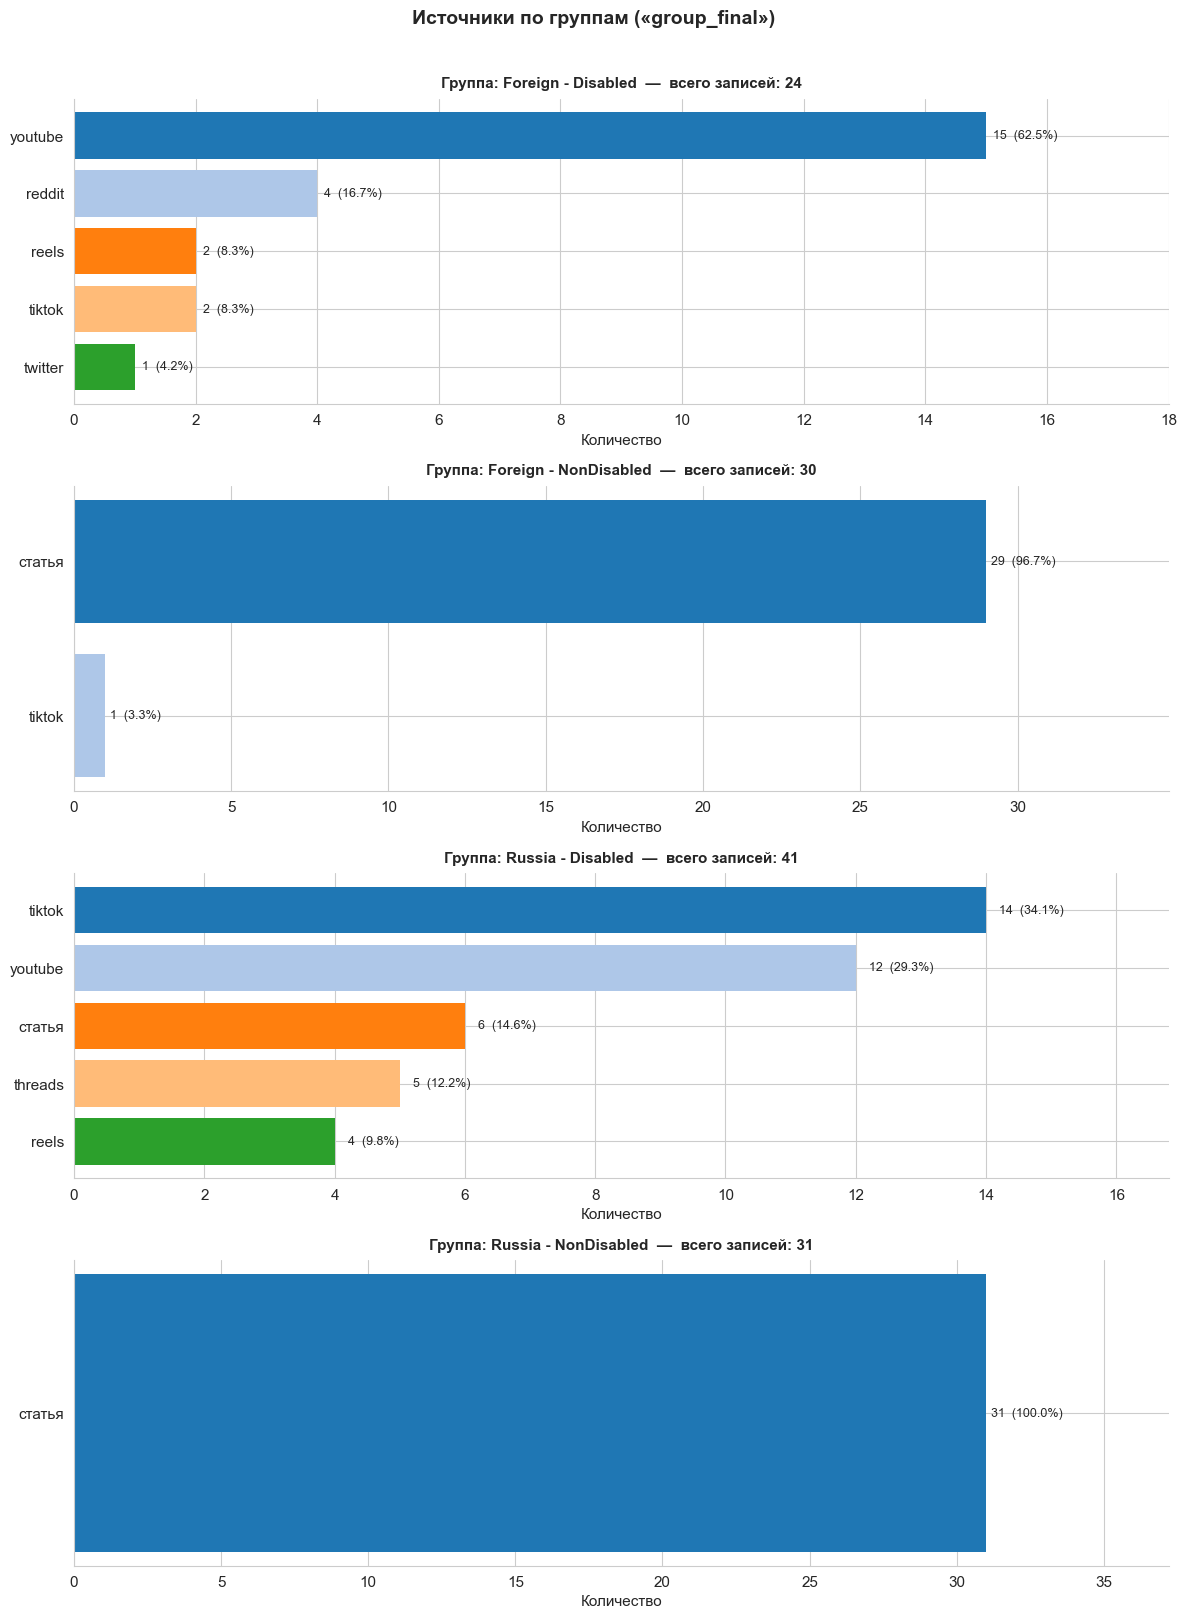

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

# Функция для анализа и визуализации источников по группам
def analyze_source_by_group(df, group_col='group_final', source_col='source', 
                             top_n=10, figsize_per_group=(12, 4)):
    groups = df[group_col].dropna().unique()
    groups = sorted(groups)

    total_rows = len(groups)
    fig, axes = plt.subplots(
        nrows=total_rows, ncols=1,
        figsize=(figsize_per_group[0], figsize_per_group[1] * total_rows)
    )

    # если группа одна — axes не список
    if total_rows == 1:
        axes = [axes]

    colors = plt.cm.tab20.colors

    for ax, group in zip(axes, groups):
        subset = df[df[group_col] == group][source_col].dropna()
        total_in_group = len(subset)

        counts = subset.value_counts().head(top_n)
        other  = subset.value_counts().iloc[top_n:].sum()

        labels = list(counts.index)
        values = list(counts.values)

        if other > 0:
            labels.append('Другие')
            values.append(other)

        bar_colors = list(colors[:len(labels)-1]) + ['#cccccc'] if other > 0 \
                     else list(colors[:len(labels)])

        bars = ax.barh(labels[::-1], values[::-1],
                       color=bar_colors[::-1], edgecolor='none')

        for bar, val in zip(bars, values[::-1]):
            pct = val / total_in_group * 100
            ax.text(bar.get_width() + total_in_group * 0.005,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:,}  ({pct:.1f}%)',
                    va='center', fontsize=9)

        ax.set_title(f'Группа: {group}  —  всего записей: {total_in_group:,}',
                     fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Количество')
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(x=0.2)

    plt.suptitle(f'Источники по группам («{group_col}»)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

df_stats = analyze_source_by_group(df)